# Ligand Similarity Evaluation per Protein
Evaluates:
1. Intra-protein pairwise similarity distributions
2. Similarity vs. affinity (pX) coverage & spread
3. Activity cliff detection
4. Per-protein Spearman correlation (similarity ↔ |ΔpX|)
5. Within-group vs. cross-group similarity by affinity bin
6. Difficulty bucket analysis

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
FIGDIR = Path('/scratch/yunmin/data/graph/train/example/eval_outputs/similarity/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('/scratch/yunmin/data/graph/train/example/eval_outputs/similarity')

FEAT_CSV   = DATA_DIR / 'bdb_df_ligand_features.csv'
PAIR_GZ    = DATA_DIR / 'bdb_df_ligand_features_all_pairwise_similarity_max_1000.csv.gz'

print('Data dir:', DATA_DIR)
print('Files:')
for f in DATA_DIR.iterdir():
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

Data dir: /scratch/yunmin/data/graph/train/example/eval_outputs/similarity
Files:
  ligand_features.csv  (143.0 MB)
  bdb_df_ligand_features_ligand_data.pkl  (707.7 MB)
  bdb_df_ligand_features_all_pairwise_similarity_max_1000.csv.gz  (7244.3 MB)
  figures  (0.0 MB)
  bdb_df_ligand_features.csv  (1487.5 MB)
  bdb_df_ligand_features_all_pairwise_similarity_max_100.csv.gz  (231.4 MB)
  figures_max_100  (0.0 MB)


**라이브러리 및 경로 설정**

- `pandas`, `numpy`: 데이터 로드 및 전처리
- `matplotlib`, `seaborn`: 시각화
- `scipy.stats`: 통계 검정 (Pearson, Spearman, Mann-Whitney, Chi-squared)
- `FEAT_CSV`: 리간드별 물리화학적 특성 + 친화도(median_pX, median_aff_nM) 정보
- `PAIR_GZ`: 단백질 내 리간드 쌍별 2D Tanimoto 유사도 (`.csv.gz` 압축)
- 생성된 그림은 모두 `FIGDIR`에 자동 저장됩니다.

## 1. Load Data

In [2]:
# Ligand features with affinity
df_feat = pd.read_csv(FEAT_CSV)
print(f'Ligand features: {df_feat.shape}  |  Proteins: {df_feat["uniprot_id"].nunique()}')
print(df_feat[['uniprot_id','ligand_smiles','median_pX','median_aff_nM']].isnull().sum().rename('nulls'))
display(df_feat.head(2))

Ligand features: (1457970, 22)  |  Proteins: 4777
uniprot_id       0
ligand_smiles    0
median_pX        0
median_aff_nM    0
Name: nulls, dtype: int64


,uniprot_id,ligand_inchikey,sequence,assay_type,protein_name,ligand_name,ligand_smiles,median_aff_nM,complex_pdb_id,ligand_het_id,...,MW,cLogP,TPSA,HBD,HBA,RotBonds,Charge,NumRings,NumAromaticRings,scaffold
0,A0A087WW23,ABNUCQPOXILHIG-UHFFFAOYSA-N,MLTFNHDAPWHTQKTLKTSEFGKSFGTLGHIGNISHQCWAGCAAGG...,Ki,Arachidonate 5-lipoxygenase-activating protein,"US8952177, 165::US9695149, 165::US9089569, 165",Cc1ccc(COc2ccc3nc(C4CCCC[C@H]4C(O)=O)n(Cc4ccc(...,12.0,NaN,NaN,...,564.608,6.31982,80.48,1,6,8,0,6,4,c1ccc(COc2ccc3nc(C4CCCCC4)n(Cc4ccc(N5CCC5)cc4)...
1,A0A087WW23,AHBHHWPCXHUMRT-UHFFFAOYSA-N,MLTFNHDAPWHTQKTLKTSEFGKSFGTLGHIGNISHQCWAGCAAGG...,Ki,Arachidonate 5-lipoxygenase-activating protein,"US8952177, 155::US9695149, 155::US9089569, 155",CCC(CC)(Cc1nc2ccc(OCc3ccn(C)n3)cc2n1Cc1ccc(cc1...,620.0,NaN,NaN,...,565.665,6.06610,85.41,1,7,11,0,5,4,c1cc(COc2ccc3ncn(Cc4ccc(N5CCCCC5)cc4)c3c2)n[nH]1


In [3]:
# Pairwise similarity (all_pairwise mode, max_ligands=1000)
df_pair = pd.read_csv(PAIR_GZ)
print(f'Pairwise similarity: {df_pair.shape}  |  Proteins: {df_pair["uniprot_id"].nunique()}')
display(df_pair.describe())

Pairwise similarity: (250374737, 6)  |  Proteins: 4384


,similarity_2d,similarity_composite
count,2.503747e+08,2.503747e+08
mean,1.841272e-01,1.841272e-01
std,1.333977e-01,1.333977e-01
min,0.000000e+00,0.000000e+00
25%,1.052632e-01,1.052632e-01
50%,1.397849e-01,1.397849e-01
75%,2.021277e-01,2.021277e-01
max,1.000000e+00,1.000000e+00


In [4]:
# Build smiles→pX lookup from features
smiles_to_pX = df_feat.set_index('ligand_smiles')['median_pX'].to_dict()

# Attach pX for both ligands in each pair
df_pair['pX_1'] = df_pair['ligand_smiles_1'].map(smiles_to_pX)
df_pair['pX_2'] = df_pair['ligand_smiles_2'].map(smiles_to_pX)

# |ΔpX| = absolute affinity difference
df_pair['delta_pX'] = (df_pair['pX_1'] - df_pair['pX_2']).abs()

# Drop pairs with missing affinity
df_pair_clean = df_pair.dropna(subset=['pX_1', 'pX_2']).copy()
print(f'Pairs after affinity join: {len(df_pair_clean):,}  '
      f'({len(df_pair_clean)/len(df_pair)*100:.1f}% of all pairs)')
print('similarity_2d :',  df_pair_clean['similarity_2d'].describe().round(3).to_dict())
print('delta_pX      :',  df_pair_clean['delta_pX'].describe().round(3).to_dict())

Pairs after affinity join: 250,374,737  (100.0% of all pairs)
similarity_2d : {'count': 250374737.0, 'mean': 0.184, 'std': 0.133, 'min': 0.0, '25%': 0.105, '50%': 0.14, '75%': 0.202, 'max': 1.0}
delta_pX      : {'count': 250374737.0, 'mean': 1.403, 'std': 1.171, 'min': 0.0, '25%': 0.477, '50%': 1.114, '75%': 2.066, 'max': 13.78}


**친화도 데이터 조인 및 |ΔpX| 계산**

- `ligand_smiles → median_pX` 딕셔너리를 만들어 pairwise 테이블의 각 리간드에 친화도를 매핑합니다.
- **|ΔpX|** = 한 쌍의 두 리간드 간 pX 절대 차이값으로, 값이 클수록 친화도 차이가 큰(=10배 이상) 쌍입니다.
  - 예: |ΔpX| = 1 → 친화도 10배 차이, |ΔpX| = 2 → 100배 차이
- 친화도 정보가 없는 쌍은 분석에서 제외합니다.

## 2. Per-Protein Similarity Distribution

In [5]:
# Per-protein summary stats
per_prot = df_pair_clean.groupby('uniprot_id').agg(
    sim_mean  = ('similarity_2d', 'mean'),
    sim_median= ('similarity_2d', 'median'),
    sim_std   = ('similarity_2d', 'std'),
    sim_max   = ('similarity_2d', 'max'),
    n_pairs   = ('similarity_2d', 'count'),
).reset_index()

print('Proteins with pairs:', len(per_prot))
display(per_prot.describe().round(3))

Proteins with pairs: 4384


,sim_mean,sim_median,sim_std,sim_max,n_pairs
count,4384.000,4384.000,4143.000,4384.000,4384.000
mean,0.312,0.273,0.161,0.869,57111.026
std,0.175,0.195,0.069,0.210,141256.389
min,0.020,0.000,0.000,0.020,1.000
25%,0.171,0.126,0.113,0.820,45.000
50%,0.260,0.172,0.159,0.984,780.000
75%,0.419,0.406,0.203,1.000,14878.000
max,1.000,1.000,0.542,1.000,1058874.000


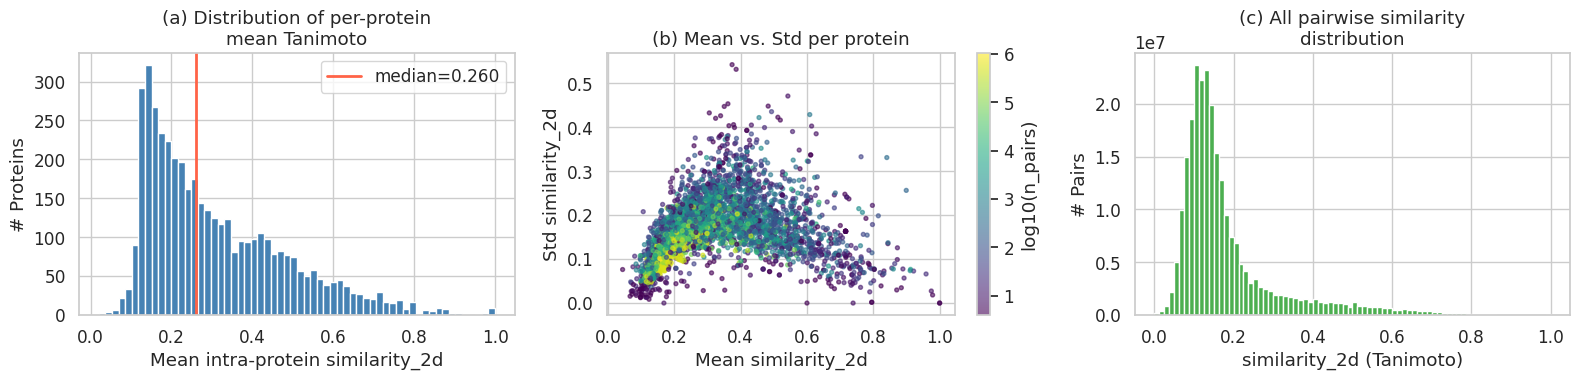

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Distribution of per-protein mean similarity
ax = axes[0]
ax.hist(per_prot['sim_mean'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(per_prot['sim_mean'].median(), color='tomato', lw=2, label=f'median={per_prot["sim_mean"].median():.3f}')
ax.set_xlabel('Mean intra-protein similarity_2d')
ax.set_ylabel('# Proteins')
ax.set_title('(a) Distribution of per-protein\nmean Tanimoto')
ax.legend()

# (b) mean vs std scatter
ax = axes[1]
sc = ax.scatter(per_prot['sim_mean'], per_prot['sim_std'],
                c=np.log10(per_prot['n_pairs']+1), cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label='log10(n_pairs)')
ax.set_xlabel('Mean similarity_2d')
ax.set_ylabel('Std similarity_2d')
ax.set_title('(b) Mean vs. Std per protein')

# (c) Overall distribution of all pairwise similarities
ax = axes[2]
ax.hist(df_pair_clean['similarity_2d'], bins=80, color='#4CAF50', edgecolor='white')
ax.set_xlabel('similarity_2d (Tanimoto)')
ax.set_ylabel('# Pairs')
ax.set_title('(c) All pairwise similarity\ndistribution')

plt.tight_layout()
plt.savefig(FIGDIR / '1_per_protein_similarity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**그림 (a)(b)(c) 해석**

- **(a) 단백질별 평균 Tanimoto 분포**: 각 단백질의 리간드 쌍 평균 유사도의 분포. 분포가 오른쪽에 치우칠수록 해당 데이터셋의 단백질들이 전반적으로 구조적으로 유사한 리간드들을 갖고 있음을 의미합니다.
- **(b) Mean vs. Std scatter**: x축은 평균 유사도, y축은 표준편차, 색은 쌍의 수. 평균이 높고 std가 낮은 단백질은 리간드가 매우 동질적(homogeneous)이며, 평균이 낮고 std가 높은 단백질은 다양한 리간드를 보유합니다.
- **(c) 전체 쌍의 유사도 분포**: 분포가 0에 쏠려 있으면 대부분의 쌍이 구조적으로 다름을, 높은 값에 쏠리면 전체적으로 구조 유사성이 높음을 의미합니다.

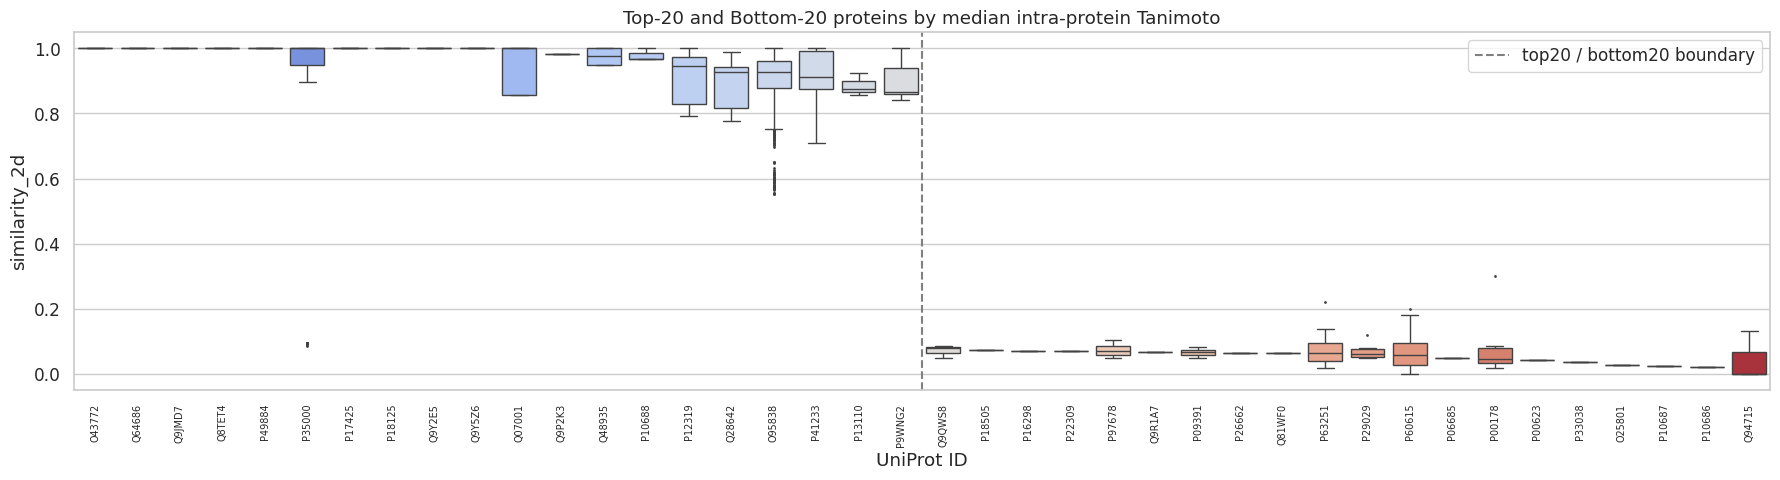

In [7]:
# Box plot: top/bottom 20 proteins by mean similarity
top20 = per_prot.nlargest(20, 'sim_mean')['uniprot_id'].tolist()
bot20 = per_prot.nsmallest(20, 'sim_mean')['uniprot_id'].tolist()
sel_ids = top20 + bot20

df_sel = df_pair_clean[df_pair_clean['uniprot_id'].isin(sel_ids)].copy()
order = (df_sel.groupby('uniprot_id')['similarity_2d']
               .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(18, 5))
sns.boxplot(data=df_sel, x='uniprot_id', y='similarity_2d', order=order,
            palette='coolwarm', fliersize=1, ax=ax)
ax.axvline(19.5, color='gray', lw=1.5, ls='--', label='top20 / bottom20 boundary')
ax.set_xlabel('UniProt ID')
ax.set_ylabel('similarity_2d')
ax.set_title('Top-20 and Bottom-20 proteins by median intra-protein Tanimoto')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '1b_top_bottom_proteins_box.png', dpi=150, bbox_inches='tight')
plt.show()

**Top-20 / Bottom-20 단백질 박스 플롯 해석**

- 단백질별 intra-protein Tanimoto 중앙값 기준으로 가장 유사도가 높은 상위 20개와 낮은 하위 20개를 시각화합니다.
- 박스의 위치(중앙값)가 높은 단백질 = 바인딩 리간드들이 구조적으로 비슷한 계열 위주 → 선택성 연구에서 scaffold-hop이 어려울 수 있습니다.
- 박스의 범위(IQR)가 넓은 단백질 = 다양한 구조의 리간드를 포용하는 단백질입니다.

## 3. Similarity vs. Affinity Difference (|ΔpX|)

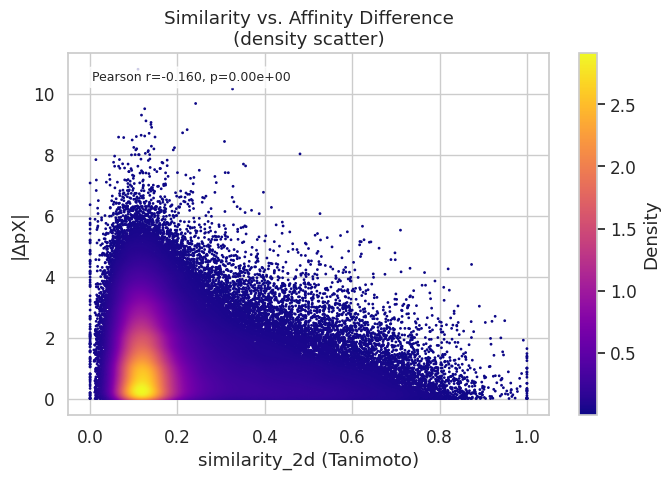

In [8]:
# Density scatter: similarity_2d vs |ΔpX|
from scipy.stats import gaussian_kde

x = df_pair_clean['similarity_2d'].values
y = df_pair_clean['delta_pX'].values

# Subsample for speed if too large
MAX_SCATTER = 200_000
if len(x) > MAX_SCATTER:
    idx = np.random.choice(len(x), MAX_SCATTER, replace=False)
    xs, ys = x[idx], y[idx]
else:
    xs, ys = x, y

# Compute density
xy = np.vstack([xs, ys])
z = gaussian_kde(xy)(xy)
sort_idx = z.argsort()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(xs[sort_idx], ys[sort_idx], c=z[sort_idx],
                s=1, cmap='plasma', rasterized=True)
plt.colorbar(sc, ax=ax, label='Density')
ax.set_xlabel('similarity_2d (Tanimoto)')
ax.set_ylabel('|ΔpX|')
ax.set_title('Similarity vs. Affinity Difference\n(density scatter)')

# Pearson r
r, p = stats.pearsonr(xs, ys)
ax.text(0.05, 0.95, f'Pearson r={r:.3f}, p={p:.2e}', transform=ax.transAxes,
        va='top', fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGDIR / '2_sim_vs_delta_pX_density.png', dpi=150, bbox_inches='tight')
plt.show()

**밀도 scatter 플롯 (similarity_2d vs |ΔpX|) 해석**

- 각 점 = 리간드 쌍 하나. 색이 밝을수록(노란색) 해당 영역에 쌍이 많이 몰려 있습니다.
- **이상적인 분포**: 유사도가 낮은(다른 구조) 쌍도 |ΔpX|가 크거나 작을 수 있고, 유사도가 높은 쌍도 마찬가지 → 유사도와 친화도 차이가 독립적으로 잘 퍼져 있어야 합니다.
- **Pearson r**: 
  - r ≈ 0 → 유사도와 친화도 차이가 선형 무상관 (데이터셋이 잘 퍼져 있음)
  - r < 0 → 구조가 비슷한 쌍일수록 친화도도 비슷한 경향 (activity cliff 적음)
  - r > 0 → 구조가 비슷할수록 오히려 친화도 차이가 더 큰 경향 (activity cliff 많음)

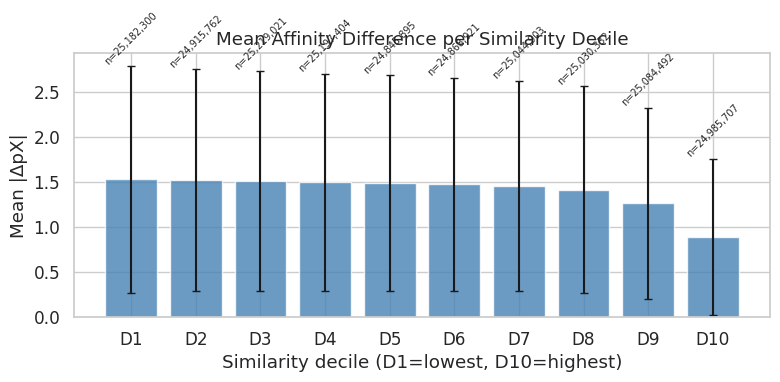

In [9]:
# Binned: mean |ΔpX| per similarity decile
df_pair_clean['sim_decile'] = pd.qcut(df_pair_clean['similarity_2d'], q=10,
                                       labels=[f'D{i}' for i in range(1,11)])
binned = df_pair_clean.groupby('sim_decile')['delta_pX'].agg(['mean','std','count']).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(binned['sim_decile'], binned['mean'], yerr=binned['std'],
       capsize=3, color='steelblue', alpha=0.8)
ax.set_xlabel('Similarity decile (D1=lowest, D10=highest)')
ax.set_ylabel('Mean |ΔpX|')
ax.set_title('Mean Affinity Difference per Similarity Decile')
for i, row in binned.iterrows():
    ax.text(i, row['mean'] + row['std'] + 0.02, f"n={int(row['count']):,}",
            ha='center', fontsize=7, rotation=45)
plt.tight_layout()
plt.savefig(FIGDIR / '2b_mean_delta_pX_per_sim_decile.png', dpi=150, bbox_inches='tight')
plt.show()

**유사도 분위별 평균 |ΔpX| 막대그래프 해석**

- similarity_2d를 10분위(D1=최저, D10=최고)로 나누어 각 구간의 평균 친화도 차이와 표준편차를 시각화합니다.
- **막대 높이가 분위별로 고른 경우**: 구조 유사도와 무관하게 친화도 차이가 고르게 존재 → well-spread 데이터셋
- **D1(저유사도)에서 막대가 높고 D10(고유사도)에서 낮은 경우**: 구조적으로 다른 리간드들이 친화도도 많이 다름 → 전형적인 SAR 패턴
- 오차막대(±1 std)와 쌍의 수(n)도 함께 표시하여 통계적 신뢰도를 확인할 수 있습니다.

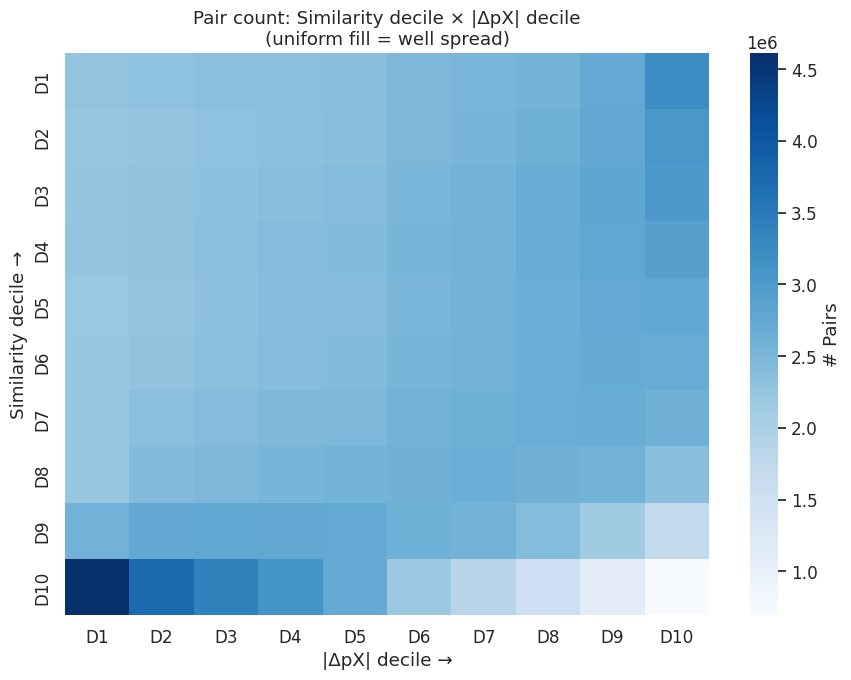

Chi-squared test of independence: χ²=7259094.8, dof=81, p=0.00e+00
(p<<0.05 means similarity and |ΔpX| are NOT independent → some structure exists)


In [10]:
# 2D count heatmap: similarity decile × |ΔpX| decile
df_pair_clean['dpX_decile'] = pd.qcut(df_pair_clean['delta_pX'], q=10,
                                        labels=[f'D{i}' for i in range(1,11)])
hmap = (df_pair_clean.groupby(['sim_decile','dpX_decile'])
                     .size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(hmap, annot=False, fmt='d', cmap='Blues', ax=ax,
            cbar_kws={'label': '# Pairs'})
ax.set_xlabel('|ΔpX| decile →')
ax.set_ylabel('Similarity decile →')
ax.set_title('Pair count: Similarity decile × |ΔpX| decile\n(uniform fill = well spread)')
plt.tight_layout()
plt.savefig(FIGDIR / '2c_sim_dpX_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Chi-squared test for independence
chi2, p_chi, dof, _ = stats.chi2_contingency(hmap.values)
print(f'Chi-squared test of independence: χ²={chi2:.1f}, dof={dof}, p={p_chi:.2e}')
print('(p<<0.05 means similarity and |ΔpX| are NOT independent → some structure exists)')

**2D 카운트 히트맵 + 카이제곱 독립성 검정 해석**

- X축 = |ΔpX| 분위, Y축 = similarity_2d 분위. 각 셀의 색 = 해당 구간에 속하는 쌍의 수입니다.
- **균일한 색분포**: 유사도와 친화도 차이가 독립적으로 고르게 분포 → 데이터셋이 모든 난이도를 커버
- **대각선 or 특정 셀 집중**: 구조 유사도와 친화도 차이 사이에 강한 패턴 존재 → 편향된 데이터셋
- **카이제곱 검정 (χ²)**: 유사도 분위와 |ΔpX| 분위가 통계적으로 독립인지 검증
  - p << 0.05 → 두 변수 사이에 유의미한 연관성 있음 (비독립)
  - p ≈ 1.0 → 임의 배치에 가까움 (독립적으로 잘 퍼짐)

## 4. Per-Protein Spearman Correlation (similarity ↔ |ΔpX|)

In [11]:
# Compute Spearman rho per protein (only proteins with ≥20 pairs)
MIN_PAIRS = 20

rows = []
for uid, grp in df_pair_clean.groupby('uniprot_id'):
    if len(grp) < MIN_PAIRS:
        continue
    rho, p = stats.spearmanr(grp['similarity_2d'], grp['delta_pX'])
    rows.append({'uniprot_id': uid, 'spearman_rho': rho, 'p_value': p, 'n_pairs': len(grp)})

df_corr = pd.DataFrame(rows)
print(f'Proteins with ≥{MIN_PAIRS} pairs: {len(df_corr)}')
display(df_corr['spearman_rho'].describe().round(3))

Proteins with ≥20 pairs: 3548


count    3539.000
mean       -0.182
std         0.192
min        -0.931
25%        -0.284
50%        -0.141
75%        -0.051
max         0.464
Name: spearman_rho, dtype: float64

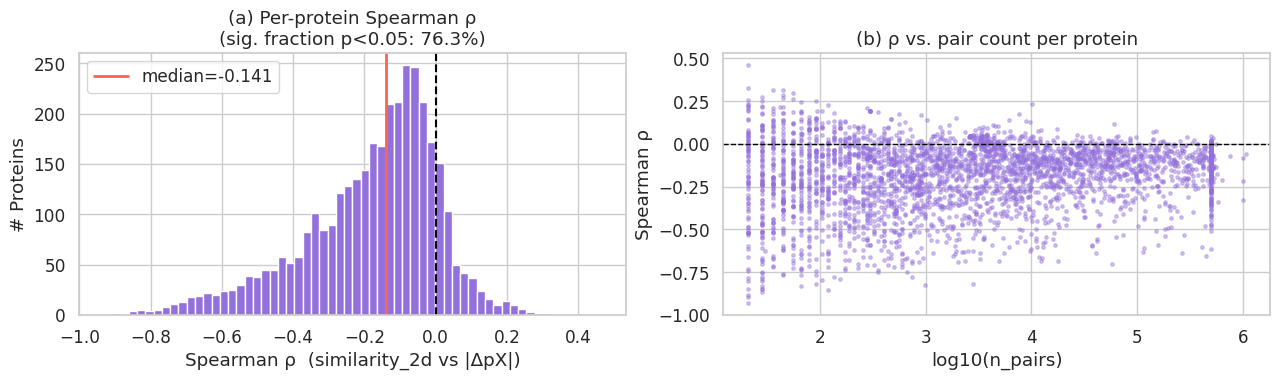

In [12]:
sig_frac = (df_corr['p_value'] < 0.05).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Distribution of Spearman rho
ax = axes[0]
ax.hist(df_corr['spearman_rho'], bins=60, color='mediumpurple', edgecolor='white')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.axvline(df_corr['spearman_rho'].median(), color='tomato', lw=2,
           label=f'median={df_corr["spearman_rho"].median():.3f}')
ax.set_xlabel('Spearman ρ  (similarity_2d vs |ΔpX|)')
ax.set_ylabel('# Proteins')
ax.set_title(f'(a) Per-protein Spearman ρ\n(sig. fraction p<0.05: {sig_frac:.1%})')
ax.legend()

# (b) rho vs log10(n_pairs)
ax = axes[1]
ax.scatter(np.log10(df_corr['n_pairs']), df_corr['spearman_rho'],
           s=6, alpha=0.4, color='mediumpurple')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('log10(n_pairs)')
ax.set_ylabel('Spearman ρ')
ax.set_title('(b) ρ vs. pair count per protein')

plt.tight_layout()
plt.savefig(FIGDIR / '3_per_protein_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

**단백질별 Spearman ρ 플롯 해석**

- **(a) ρ 분포 히스토그램**: 각 단백질에서 "유사도가 높을수록 친화도 차이가 줄어드는가"를 나타내는 Spearman 상관계수 분포입니다.
  - ρ ≈ 0에 집중 → 단백질 내에서 유사도와 친화도 차이가 무상관 (activity cliff가 무작위로 존재)
  - ρ < 0이 많음 → 구조적으로 비슷한 리간드일수록 친화도도 비슷한 경향 (전형적 SAR)
  - ρ > 0이 많음 → 구조적으로 비슷한 리간드 쌍에 activity cliff가 많음
  - **유의미 비율** (p<0.05): 통계적으로 신뢰할 수 있는 상관을 보이는 단백질 비율
- **(b) ρ vs. log10(n_pairs)**: 쌍의 수가 적은 단백질은 ρ가 극단적으로 나올 수 있으므로, 쌍이 많을수록 ρ가 0에 수렴하는지 확인합니다.

## 5. Activity Cliff Analysis

In [13]:
# Activity cliff: high structural similarity but large affinity difference
SIM_THRESH  = 0.70   # Tanimoto ≥ 0.7 → structurally similar
DPAX_THRESH = 1.0    # |ΔpX| ≥ 1 → 10× affinity difference

df_pair_clean['is_cliff'] = (
    (df_pair_clean['similarity_2d'] >= SIM_THRESH) &
    (df_pair_clean['delta_pX']      >= DPAX_THRESH)
)

total_pairs = len(df_pair_clean)
cliff_pairs = df_pair_clean['is_cliff'].sum()
print(f'Activity cliffs: {cliff_pairs:,} / {total_pairs:,}  ({cliff_pairs/total_pairs*100:.2f}%)')

# Per-protein cliff rate
cliff_rate = (df_pair_clean.groupby('uniprot_id')
              .apply(lambda g: g['is_cliff'].sum() / len(g))
              .reset_index(name='cliff_rate'))

display(cliff_rate['cliff_rate'].describe().round(4))

Activity cliffs: 515,699 / 250,374,737  (0.21%)


count    4384.0000
mean        0.0230
std         0.0773
min         0.0000
25%         0.0000
50%         0.0021
75%         0.0123
max         1.0000
Name: cliff_rate, dtype: float64

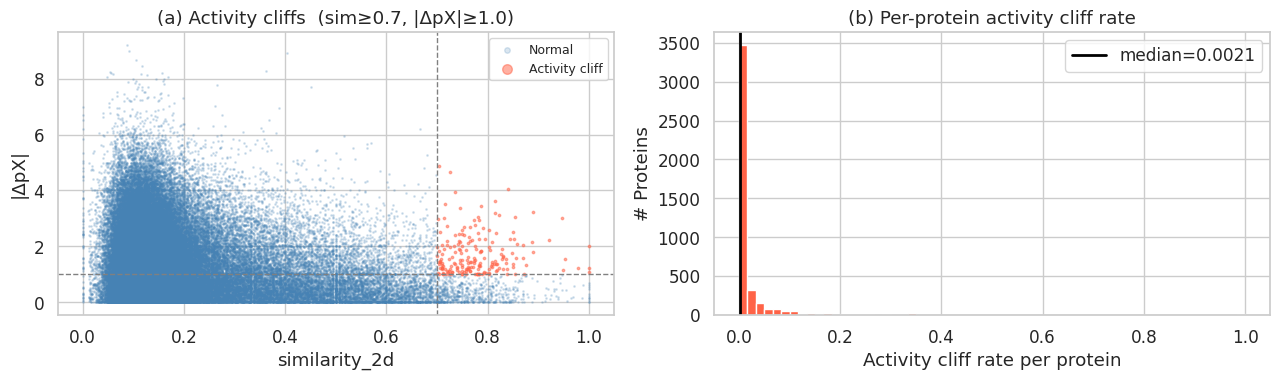

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Scatter with cliff highlighting
ax = axes[0]
MAX_PLOT = 100_000
sample = df_pair_clean.sample(min(MAX_PLOT, len(df_pair_clean)), random_state=42)
non_cliff = sample[~sample['is_cliff']]
cliff     = sample[sample['is_cliff']]
ax.scatter(non_cliff['similarity_2d'], non_cliff['delta_pX'],
           s=1, alpha=0.2, color='steelblue', label='Normal', rasterized=True)
ax.scatter(cliff['similarity_2d'], cliff['delta_pX'],
           s=3, alpha=0.5, color='tomato', label='Activity cliff', rasterized=True)
ax.axvline(SIM_THRESH,  color='gray', lw=1, ls='--')
ax.axhline(DPAX_THRESH, color='gray', lw=1, ls='--')
ax.set_xlabel('similarity_2d')
ax.set_ylabel('|ΔpX|')
ax.set_title(f'(a) Activity cliffs  (sim≥{SIM_THRESH}, |ΔpX|≥{DPAX_THRESH})')
ax.legend(markerscale=4, fontsize=9)

# (b) Distribution of cliff rate per protein
ax = axes[1]
ax.hist(cliff_rate['cliff_rate'], bins=60, color='tomato', edgecolor='white')
ax.set_xlabel('Activity cliff rate per protein')
ax.set_ylabel('# Proteins')
ax.set_title('(b) Per-protein activity cliff rate')
ax.axvline(cliff_rate['cliff_rate'].median(), color='black', lw=2,
           label=f'median={cliff_rate["cliff_rate"].median():.4f}')
ax.legend()

plt.tight_layout()
plt.savefig(FIGDIR / '4_activity_cliff.png', dpi=150, bbox_inches='tight')
plt.show()

**Activity Cliff 플롯 해석**

- **Activity Cliff 정의**: Tanimoto ≥ 0.70 (구조적으로 유사) 이면서 |ΔpX| ≥ 1.0 (친화도 10배 이상 차이)인 리간드 쌍입니다.
- **(a) Scatter**: 빨간 점 = activity cliff 쌍. 회색 점선(sim=0.7, |ΔpX|=1.0)의 우상단 사분면에 위치합니다.
  - Activity cliff가 많다 → 미세한 구조 변화로도 큰 친화도 변화 → 정확한 구조-활성 관계(SAR) 모델링이 필요
- **(b) 단백질별 cliff rate 히스토그램**: 단백질마다 activity cliff 비율이 얼마나 다른지 분포를 확인합니다.
  - 분포가 0에 집중 → 대부분의 단백질에서 cliff가 드뭄 (데이터셋이 SAR 연속적)
  - 넓게 퍼져 있음 → 특정 단백질은 cliff가 많고 어떤 단백질은 거의 없음 → 단백질 특이적 패턴

## 6. Within-Group vs. Cross-Group Similarity by Affinity Bin

In [15]:
# Assign each ligand to affinity quantile group (Low / Mid / High) per protein
ALL_LABELS = ['Low', 'Mid', 'High']

def assign_affinity_bin(grp):
    grp = grp.copy()
    try:
        bins = pd.qcut(grp['median_pX'], q=3, duplicates='drop')
        n_bins = bins.cat.categories.shape[0]
        grp['aff_bin'] = pd.qcut(grp['median_pX'], q=3,
                                  labels=ALL_LABELS[-n_bins:],
                                  duplicates='drop')
    except ValueError:
        grp['aff_bin'] = np.nan
    return grp

df_binned = (df_feat.groupby('uniprot_id', group_keys=False)
                    .apply(assign_affinity_bin)
                    .dropna(subset=['aff_bin']))

smiles_to_bin = df_binned.set_index('ligand_smiles')['aff_bin'].to_dict()

df_pair_clean['bin_1'] = df_pair_clean['ligand_smiles_1'].map(smiles_to_bin)
df_pair_clean['bin_2'] = df_pair_clean['ligand_smiles_2'].map(smiles_to_bin)

df_grp = df_pair_clean.dropna(subset=['bin_1','bin_2']).copy()
df_grp['same_bin'] = df_grp['bin_1'] == df_grp['bin_2']

print('Pairs with bin labels:', len(df_grp))
display(df_grp.groupby('same_bin')['similarity_2d'].describe().round(3))


Pairs with bin labels: 250359882


,count,mean,std,min,25%,50%,75%,max
same_bin,,,,,,,,
False,161567398.0,0.175,0.121,0.0,0.104,0.138,0.193,1.0
True,88792484.0,0.201,0.152,0.0,0.108,0.144,0.224,1.0


**친화도 분위 그룹 할당 설명**

- 각 단백질 내에서 리간드를 median_pX 기준 3분위로 분류합니다: **Low** (낮은 친화도), **Mid**, **High** (높은 친화도)
- 분류는 단백질 내부 상대적 순위 기준이므로, 절대적 pX 값이 아닌 해당 단백질 내에서의 상대적 위치를 나타냅니다.
- `duplicates='drop'` + 동적 label 수 조정: 단백질 내 리간드 수가 적어 구간이 2개만 생기는 경우도 처리합니다.
- 이후 리간드 쌍에 bin 정보를 붙여 **같은 친화도 그룹 내 pair (same_bin=True)** vs **다른 그룹 간 pair (same_bin=False)** 를 비교합니다.

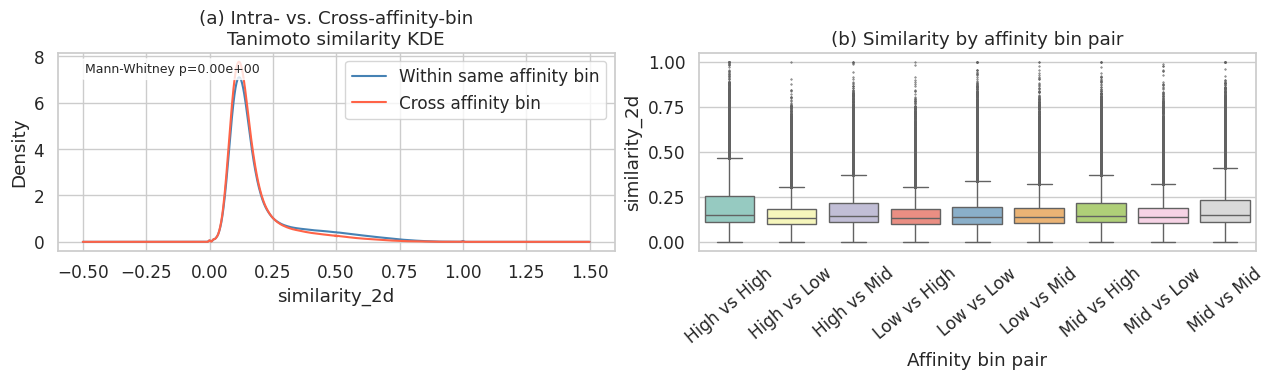

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Within vs. cross group similarity KDE
ax = axes[0]
for same, label, color in [(True, 'Within same affinity bin', 'steelblue'),
                            (False, 'Cross affinity bin',      'tomato')]:
    s = df_grp[df_grp['same_bin']==same]['similarity_2d']
    s.plot.kde(ax=ax, label=label, color=color)
ax.set_xlabel('similarity_2d')
ax.set_ylabel('Density')
ax.set_title('(a) Intra- vs. Cross-affinity-bin\nTanimoto similarity KDE')
ax.legend()

# Mann-Whitney U test
u, p_mw = stats.mannwhitneyu(
    df_grp[df_grp['same_bin']]['similarity_2d'],
    df_grp[~df_grp['same_bin']]['similarity_2d'],
    alternative='two-sided'
)
ax.text(0.05, 0.95, f'Mann-Whitney p={p_mw:.2e}', transform=ax.transAxes,
        va='top', fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# (b) Box plot: similarity by bin_1 × bin_2
ax = axes[1]
df_grp['pair_type'] = df_grp['bin_1'].astype(str) + ' vs ' + df_grp['bin_2'].astype(str)
order_pairs = sorted(df_grp['pair_type'].unique())
sample_b = df_grp.sample(min(200_000, len(df_grp)), random_state=42)
sns.boxplot(data=sample_b, x='pair_type', y='similarity_2d',
            order=order_pairs, palette='Set3', fliersize=0.5, ax=ax)
ax.set_xlabel('Affinity bin pair')
ax.set_ylabel('similarity_2d')
ax.set_title('(b) Similarity by affinity bin pair')
ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(FIGDIR / '5_within_cross_group_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

**Within vs. Cross affinity bin 플롯 해석**

- **(a) KDE**: 같은 친화도 그룹 내 쌍(파란색)과 다른 그룹 간 쌍(빨간색)의 유사도 분포를 비교합니다.
  - **파란선이 빨간선보다 오른쪽에 위치**: 같은 친화도 수준의 리간드들이 구조적으로도 더 비슷한 경향 → 구조와 친화도가 어느 정도 연관되어 있음
  - **두 선이 거의 겹침**: 유사도가 친화도 그룹과 무관하게 분포 → 다양한 구조로 같은 친화도를 달성 가능
  - **Mann-Whitney U 검정**: 두 분포가 통계적으로 유의하게 다른지 검증. p << 0.05이면 유의한 차이 존재
- **(b) Box plot (pair_type별)**: Low vs Low, Low vs Mid, ... High vs High 등 모든 조합의 유사도 분포를 한눈에 비교합니다. 대각선(같은 bin 쌍)이 비대각선보다 유사도가 높은지 확인하세요.

## 7. Is Affinity Well-Spread Across Similarity Range?

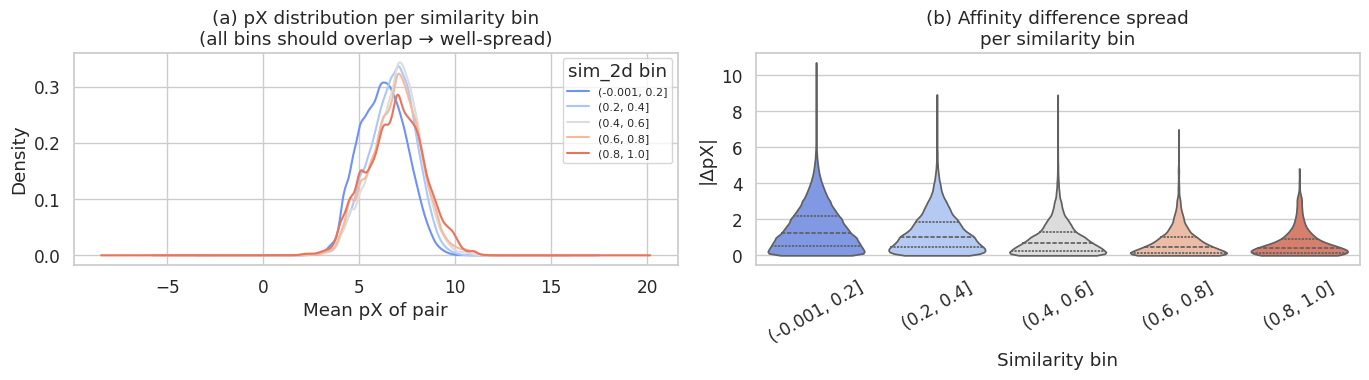

In [17]:
# For each pair, compute mean pX of the pair
df_pair_clean['mean_pX'] = (df_pair_clean['pX_1'] + df_pair_clean['pX_2']) / 2

# Bin similarity into 5 equal-width bins
df_pair_clean['sim_bin5'] = pd.cut(df_pair_clean['similarity_2d'], bins=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) KDE of mean_pX colored by similarity bin
ax = axes[0]
palette = sns.color_palette('coolwarm', n_colors=5)
for (label, grp), color in zip(df_pair_clean.groupby('sim_bin5', observed=True), palette):
    sample_g = grp.sample(min(50_000, len(grp)), random_state=42)
    sample_g['mean_pX'].plot.kde(ax=ax, label=str(label), color=color)
ax.set_xlabel('Mean pX of pair')
ax.set_ylabel('Density')
ax.set_title('(a) pX distribution per similarity bin\n(all bins should overlap → well-spread)')
ax.legend(title='sim_2d bin', fontsize=8)

# (b) Violin of delta_pX per similarity bin
ax = axes[1]
order_bins = df_pair_clean['sim_bin5'].cat.categories.tolist()
sample_v = df_pair_clean.sample(min(200_000, len(df_pair_clean)), random_state=42)
sns.violinplot(data=sample_v, x='sim_bin5', y='delta_pX', order=order_bins,
               palette='coolwarm', inner='quartile', cut=0, ax=ax)
ax.set_xlabel('Similarity bin')
ax.set_ylabel('|ΔpX|')
ax.set_title('(b) Affinity difference spread\nper similarity bin')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGDIR / '6_affinity_spread_by_sim_bin.png', dpi=150, bbox_inches='tight')
plt.show()

**유사도 구간별 친화도 퍼짐 플롯 해석**

- similarity_2d를 5개 등간격 구간으로 나누어 각 구간의 친화도 분포를 확인합니다.
- **(a) pX KDE (유사도 구간별)**: 각 유사도 구간에서 쌍의 평균 pX 분포를 KDE로 시각화합니다.
  - **모든 구간의 KDE가 겹쳐 있음** → 유사도와 무관하게 모든 친화도 범위에 리간드 쌍이 존재 → **데이터셋이 친화도 측면에서 잘 퍼져 있음**
  - **특정 구간 KDE만 집중** → 구조적으로 유사한 리간드들만 특정 친화도 범위에 집중 → 편향 가능성
- **(b) Violin plot (|ΔpX|)**: 유사도 구간별 친화도 차이의 분포를 violin으로 나타냅니다.
  - 모든 구간의 violin이 비슷한 모양 → 유사도와 무관하게 친화도 차이가 고르게 존재 (이상적)
  - 고유사도 구간에서 |ΔpX|가 작게 집중 → activity cliff가 드문 전형적 SAR 패턴

## 8. Summary Statistics Table

In [18]:
summary = {
    'Total ligand-protein pairs (features)': len(df_feat),
    'Unique proteins (features)':            df_feat['uniprot_id'].nunique(),
    'Total pairwise pairs (similarity)':     len(df_pair),
    'Pairs with affinity annotation':        len(df_pair_clean),
    'Mean similarity_2d (all pairs)':        df_pair_clean['similarity_2d'].mean(),
    'Median similarity_2d':                  df_pair_clean['similarity_2d'].median(),
    'Mean |ΔpX|':                            df_pair_clean['delta_pX'].mean(),
    'Median |ΔpX|':                          df_pair_clean['delta_pX'].median(),
    f'Activity cliff pairs (sim≥{SIM_THRESH}, |ΔpX|≥{DPAX_THRESH})': cliff_pairs,
    'Activity cliff rate (%)':               f'{cliff_pairs/total_pairs*100:.2f}',
    'Median per-protein Spearman ρ':         df_corr['spearman_rho'].median(),
    'Fraction proteins sig. corr (p<0.05)':  f'{sig_frac:.1%}',
    'Mann-Whitney p (within vs cross bin)':  f'{p_mw:.2e}',
}

df_summary = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
display(df_summary)
df_summary.to_csv(FIGDIR / 'summary_stats.csv')
print(f'\nAll figures saved to {FIGDIR}')

,Value
Total ligand-protein pairs (features),1457970
Unique proteins (features),4777
Total pairwise pairs (similarity),250374737
Pairs with affinity annotation,250374737
Mean similarity_2d (all pairs),0.184127
Median similarity_2d,0.139785
Mean |ΔpX|,1.403374
Median |ΔpX|,1.114401
"Activity cliff pairs (sim≥0.7, |ΔpX|≥1.0)",515699
Activity cliff rate (%),0.21



All figures saved to /scratch/yunmin/data/graph/train/example/eval_outputs/similarity/figures


**Summary Table 해석 가이드**

| 지표 | 해석 기준 |
|------|-----------|
| Mean/Median similarity_2d | 값이 낮을수록 구조적으로 다양한 리간드 쌍이 많음 |
| Mean/Median \|ΔpX\| | 값이 클수록 친화도가 넓게 퍼져 있음 (다양한 세기의 바인더 보유) |
| Activity cliff rate | 높을수록 미세 구조 변화에 친화도가 민감한 데이터셋 |
| Median Spearman ρ | ≈0이면 유사도와 친화도 차이가 독립적 (잘 설계된 데이터셋) |
| Fraction sig. corr | 낮을수록 대부분의 단백질에서 유사도↔친화도 패턴이 우연적 수준 |
| Mann-Whitney p | p << 0.05이면 같은 친화도 그룹의 리간드들이 구조적으로 통계적으로 더 유사 |

결과는 `summary_stats.csv`로도 저장됩니다.